In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr


In [21]:
df = pd.read_csv("spotify-tracks-dataset-detailed.csv")

In [22]:
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

Removing duplicate and null values

In [24]:
df.isnull().sum()
df.dropna()
df.drop_duplicates()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


creation duration_min

In [25]:
df['duration_min'] = df['duration_ms']/60000
df['duration_min'] = df['duration_min'].round(4)
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,3.8444
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,2.4935
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,3.5138
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,3.3656
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,3.3142


Startified Sampling : 

Creating Starta :

In [26]:
def duration_group(x):
    if x < 3:
        return 'short'
    elif x <= 5:
        return 'medium'
    else:
        return 'long'
    
df['group'] = df['duration_min'].apply(duration_group)
print(df['group'].value_counts())

group
medium    65329
short     32325
long      16346
Name: count, dtype: int64


In [27]:
sample_df = (
    df.groupby('group', group_keys=False)
    .sample(n = 1000, random_state=42)
    .reset_index(drop=True)
)

print(sample_df.info())
print(sample_df.shape)
print(sample_df['group'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          3000 non-null   object 
 1   artists           3000 non-null   object 
 2   album_name        3000 non-null   object 
 3   track_name        3000 non-null   object 
 4   popularity        3000 non-null   int64  
 5   duration_ms       3000 non-null   int64  
 6   explicit          3000 non-null   bool   
 7   danceability      3000 non-null   float64
 8   energy            3000 non-null   float64
 9   key               3000 non-null   int64  
 10  loudness          3000 non-null   float64
 11  mode              3000 non-null   int64  
 12  speechiness       3000 non-null   float64
 13  acousticness      3000 non-null   float64
 14  instrumentalness  3000 non-null   float64
 15  liveness          3000 non-null   float64
 16  valence           3000 non-null   float64


Hypothesis Testing :

1 Null Hypothesis - Song Duration Affect Rating

2 Alternate Hypothesis - Song Duration does not Affect rating.


In [28]:
short_song_popularity = sample_df[sample_df['group'] == 'short']['popularity']
long_song_popularity = sample_df[sample_df['group'] == 'long']['popularity']
print(short_song_popularity.value_counts().sum())
print(long_song_popularity.value_counts().sum())
# Finding Mean
short_mean = short_song_popularity.mean()
short_mean = short_mean.round(4)
long_mean = long_song_popularity.mean()
long_mean = long_mean.round(4)
print(f"Short mean : {short_mean}")
print(f"long mean : {long_mean}")
# Finding Standard Deviation for Samples
short_std = short_song_popularity.std(ddof=1)
long_std = long_song_popularity.std(ddof=1)
print(f"Short Standard Deviation : {short_std}")
print(f"long Standard Deviation : {long_std}")

1000
1000
Short mean : 32.224
long mean : 31.76
Short Standard Deviation : 22.5710273420435
long Standard Deviation : 20.690928314469474


Z-test

In [29]:
n1 = 1000
n2 = 1000
Z = (short_mean - long_mean)/np.sqrt(((short_std)**2/n1)+((long_std)**2/n2))
Z = Z.round(4)
print(Z)

0.4792


As the Value is smaller than 1.96. So, by 5% Level of Significance we can conclude that the Null hypothesis is Accepted i.e. Long Songs and Short Songs both have Same Rating.

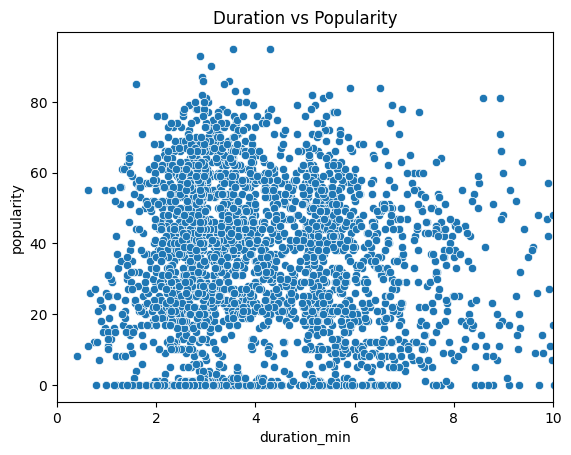

In [30]:
sns.scatterplot(x='duration_min', y='popularity', data=sample_df)
plt.title("Duration vs Popularity")
plt.xlim(0,10)
plt.show()

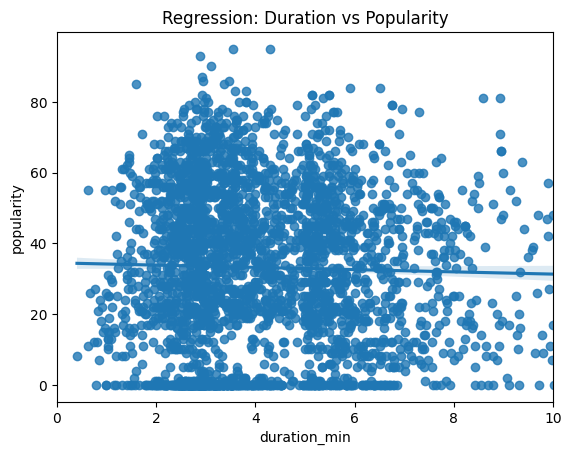

In [31]:
sns.regplot(x='duration_min', y='popularity', data=sample_df)
plt.title("Regression: Duration vs Popularity")
plt.xlim(0,10)
plt.show()

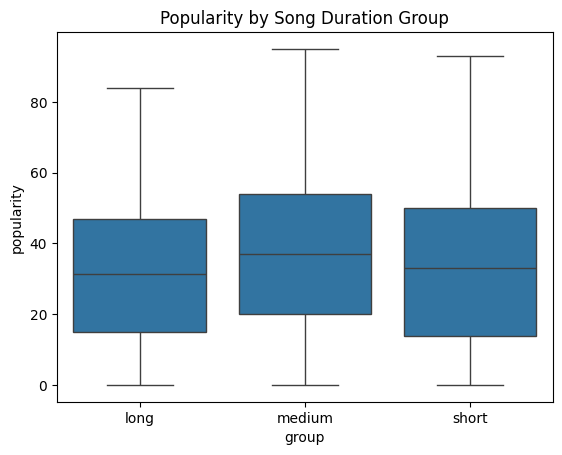

In [32]:
sns.boxplot(x='group', y='popularity', data=sample_df)
plt.title("Popularity by Song Duration Group")
plt.show()

In [33]:
corr, p_value = pearsonr(sample_df['duration_min'], sample_df['popularity'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.030420516638276385
P-value: 0.09573503565098557
